In [ ]:
# 1. IMPORTAÇÕES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, roc_auc_score)

# Configurações visuais
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [ ]:
# 2. CARREGAR DADOS
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Shape dos dados:", X.shape)
print("Distribuição das classes:\n", y.value_counts())
print("\nExemplo de características:\n", X.head())


Shape dos dados: (569, 30)
Distribuição das classes:
 target
1    357
0    212
Name: count, dtype: int64

Exemplo de características:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.19

In [ ]:
# 3. DIVISÃO TREINO (60%), VALIDAÇÃO (20%), TESTE (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)  # 0.25 de 80% = 20% do total

print(f"\nTreino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")


Treino: 341 amostras
Validação: 114 amostras
Teste: 114 amostras


In [ ]:
# 4. PADRONIZAÇÃO (fit apenas no treino)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 5. DEFINIÇÃO DOS MODELOS E GRID SEARCH (usando validação cruzada no treino)

# Dicionário com modelos e seus grids de hiperparâmetros
models_grid = {
    'Regressão Logística': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
    },
    'Árvore de Decisão': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, None],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, None]
        }
    }
}

# Estrutura para armazenar os melhores modelos e resultados
best_models = {}
cv_results = {}

for name, config in models_grid.items():
    print(f"\n=== Ajustando {name} via GridSearchCV ===")
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',  # otimiza F1-score (balanceia precisão e recall)
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train_scaled, y_train)

    best_models[name] = grid.best_estimator_
    cv_results[name] = {
        'best_params': grid.best_params_,
        'best_cv_score': grid.best_score_
    }
    print(f"Melhores parâmetros: {grid.best_params_}")
    print(f"Melhor F1 (validação cruzada): {grid.best_score_:.4f}")


=== Ajustando Regressão Logística via GridSearchCV ===
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Melhores parâmetros: {'C': 0.1, 'penalty': 'l2'}
Melhor F1 (validação cruzada): 0.9817

=== Ajustando Árvore de Decisão via GridSearchCV ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'max_depth': 3, 'min_samples_split': 2}
Melhor F1 (validação cruzada): 0.9448

=== Ajustando Random Forest via GridSearchCV ===
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Melhores parâmetros: {'max_depth': 5, 'n_estimators': 100}
Melhor F1 (validação cruzada): 0.9747


In [ ]:
# 6. AVALIAÇÃO NO CONJUNTO DE VALIDAÇÃO (para escolha final – já foi via CV)
#    Vamos apenas avaliar no conjunto de validação para conferência
val_results = {}
for name, model in best_models.items():
    y_val_pred = model.predict(X_val_scaled)
    val_results[name] = {
        'Acurácia': accuracy_score(y_val, y_val_pred),
        'Precisão': precision_score(y_val, y_val_pred),
        'Recall': recall_score(y_val, y_val_pred),
        'F1-Score': f1_score(y_val, y_val_pred)
    }
print("\n===== DESEMPENHO NO CONJUNTO DE VALIDAÇÃO =====")
val_df = pd.DataFrame(val_results).T.round(4)
print(val_df)



===== DESEMPENHO NO CONJUNTO DE VALIDAÇÃO =====
                     Acurácia  Precisão  Recall  F1-Score
Regressão Logística    0.9737    0.9595  1.0000    0.9793
Árvore de Decisão      0.9386    0.9324  0.9718    0.9517
Random Forest          0.9474    0.9577  0.9577    0.9577


In [ ]:
# 7. AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (comparação definitiva)
test_results = {}
y_probas = {}

for name, model in best_models.items():
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

    test_results[name] = {
        'Acurácia': accuracy_score(y_test, y_test_pred),
        'Precisão': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1-Score': f1_score(y_test, y_test_pred),
        'AUC': roc_auc_score(y_test, y_test_proba)
    }
    y_probas[name] = y_test_proba

# Tabela comparativa final
test_df = pd.DataFrame(test_results).T.round(4)
print("\n===== RESULTADOS FINAIS NO CONJUNTO DE TESTE =====")
print(test_df)



===== RESULTADOS FINAIS NO CONJUNTO DE TESTE =====
                     Acurácia  Precisão  Recall  F1-Score     AUC
Regressão Logística    0.9737    0.9726  0.9861    0.9793  0.9960
Árvore de Decisão      0.9386    0.9577  0.9444    0.9510  0.9547
Random Forest          0.9474    0.9583  0.9583    0.9583  0.9940


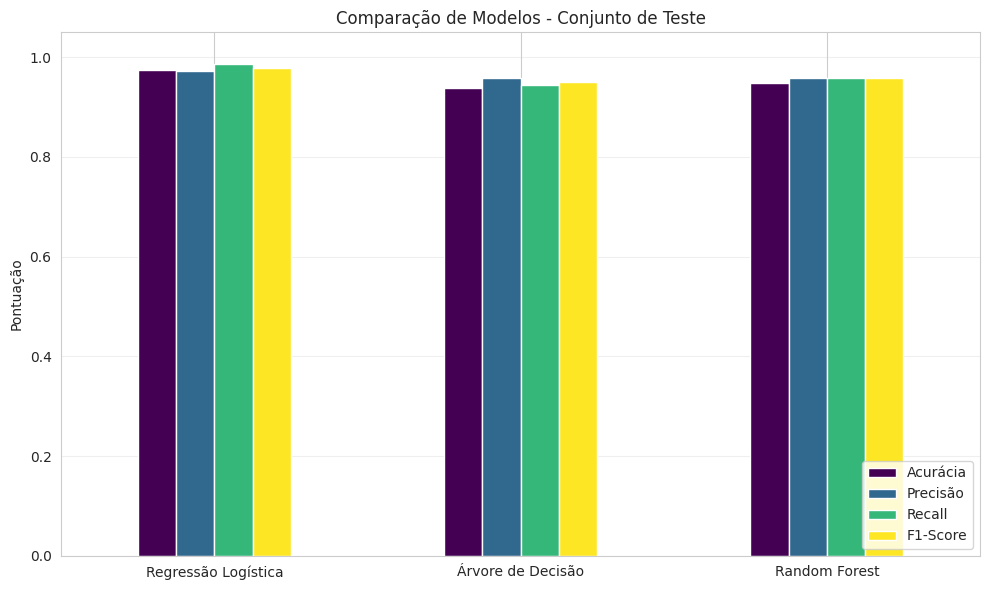

In [ ]:
# 8. GRÁFICO DE BARRAS COMPARATIVO
metrics = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
test_df[metrics].plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title('Comparação de Modelos - Conjunto de Teste')
plt.ylabel('Pontuação')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparacao_modelos.png')
plt.show()


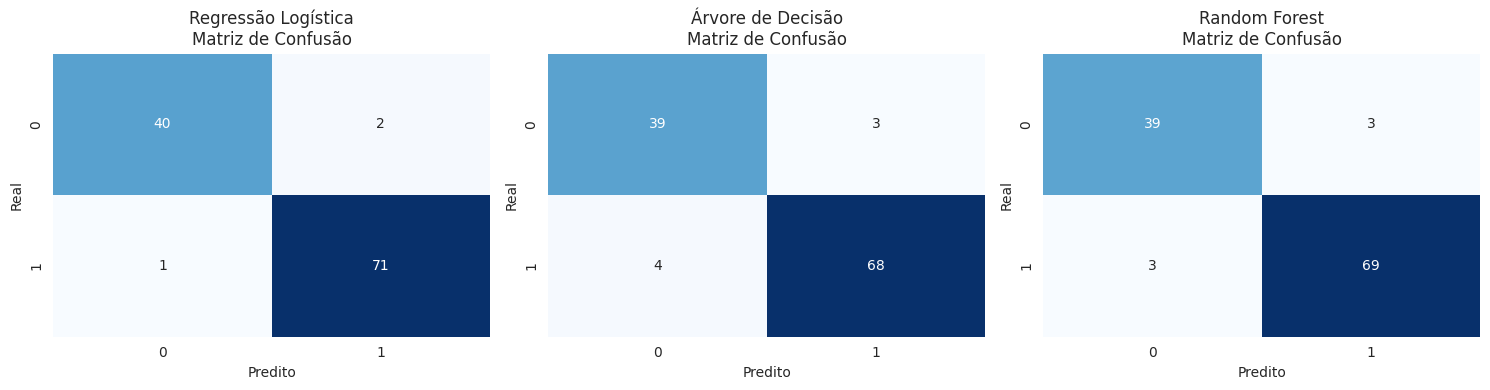

In [ ]:
# 9. MATRIZES DE CONFUSÃO (teste)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}\nMatriz de Confusão')
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')
plt.tight_layout()
plt.savefig('matrizes_confusao.png')
plt.show()


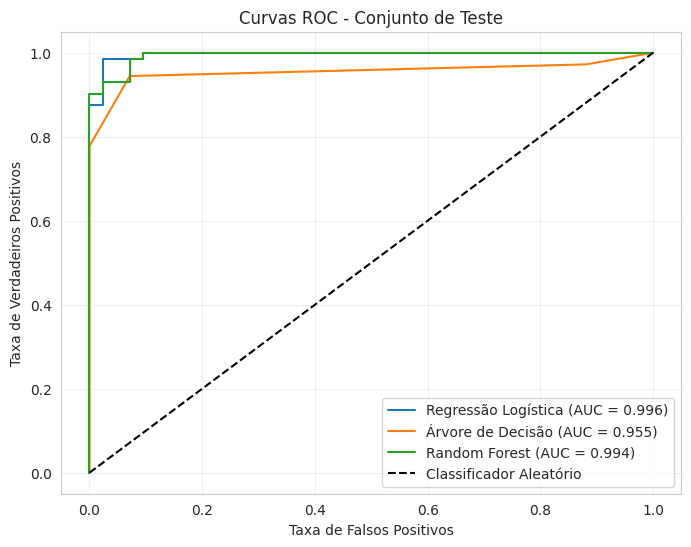

In [ ]:
# 10. CURVAS ROC
plt.figure(figsize=(8,6))
for name, proba in y_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = test_results[name]['AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Classificador Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC - Conjunto de Teste')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('curvas_roc.png')
plt.show()

In [ ]:
# 11. EXIBIR MELHORES HIPERPARÂMETROS ENCONTRADOS
print("\n===== MELHORES HIPERPARÂMETROS (GRID SEARCH) =====")
for name, res in cv_results.items():
    print(f"{name}: {res['best_params']} -> F1 CV = {res['best_cv_score']:.4f}")


===== MELHORES HIPERPARÂMETROS (GRID SEARCH) =====
Regressão Logística: {'C': 0.1, 'penalty': 'l2'} -> F1 CV = 0.9817
Árvore de Decisão: {'max_depth': 3, 'min_samples_split': 2} -> F1 CV = 0.9448
Random Forest: {'max_depth': 5, 'n_estimators': 100} -> F1 CV = 0.9747
